# Projeto de Machine Learning Social Media

> Link do Dataset: https://www.kaggle.com/datasets/rockyt07/social-media-user-analysis?select=instagram_usage_lifestyle.csv

### Comportamento e estilo de vida dos usuários de mídias sociais – 1 milhão de usuários sintéticos (Instagram com base em 2025–2026)
<li>Este conjunto de dados contém mais de 1.000.000 de perfis de usuários totalmente sintéticos que simulam de forma realista os padrões de uso do Instagram, combinados com atributos demográficos, de estilo de vida, saúde e comportamento detalhados.

Todos os dados são 100% sintéticos — gerados usando distribuições estatísticas e correlações realistas.

Nenhum dado real de usuário foi usado ou coletado. Perfeitamente seguro para pesquisa, educação, prototipagem e competições do Kaggle.



#### Descrição do Dataset
<li>Temas e colunas principais:<br>
<b>Dados demográficos e histórico (19 colunas)</b>
age, gender, country, urban_rural, income_level, employment_status, education_level, relationship_status, has_children.

<b>Estilo de vida e saúde (10 colunas)</b>
exercise_hours_per_week, sleep_hours_per_night, diet_quality, smoking, alcohol_frequency, perceived_stress_score, self_reported_happiness, body_mass_index, blood_pressure_systolic, blood_pressure_diastolic, daily_steps_count.

<b>Hábitos diários/semanais (8 colunas)</b>
weekly_work_hours, hobbies_count, social_events_per_month, books_read_per_year, volunteer_hours_per_month, travel_frequency_per_year.

<b>Uso e engajamento no Instagram (17 colunas)</b>
daily_active_minutes_instagram, sessions_per_day, posts_created_per_week, reels_watched_per_day, stories_viewed_per_day, likes_given_per_day, comments_written_per_day, dms_sent_per_week, dms_received_per_week, ads_viewed_per_day, ads_clicked_per_day, time_on_feed_per_day, time_on_explore_per_day, time_on_messages_per_day, time_on_reels_per_day, followers_count, following_count, notification_response_rate, average_session_length_minutes, content_type_preference, preferred_content_theme, privacy_setting_level, two_factor_auth_enabled, biometric_login_used, linked_accounts_count, subscription_status, user_engagement_score, account_creation_year, last_login_date, uses_premium_features.</li>

<li>Exploratory Data Analysis (EDA) – discover links between screen time & well-being
    
Predictive modeling – predict happiness/stress/sleep from usage patterns

Clustering – identify user personas (doom-scroller, casual poster, aspiring influencer, etc.)

A/B testing simulation – study behavioral effects

Education & tutorials – great for teaching correlation, regression, feature engineering, large dataset handling

Benchmarking – compare synthetic patterns vs real-world social media studies

100% synthetic – no real user data was accessed or used

## Objetivo do projeto
<h4> Buscar através de modelos de ML, prever o nível de estresse de usuários do instagram, e como variáveis podem impactar o estresse<br></h4>

## Etapas a serem abordadas
<br>1️⃣<b> Entendimento do problema</b><br>
Prever o nível de estresse
<br>
<br>2️⃣<b> EAD:</b><br>
Estrutura do dataset<br>
Tipos de variáveis<br>
Distribuições<br>
Valores Faltantes<br>
Outliers<br>
<Br>3️⃣<b> Pré processamento dos dados</b><br>
Limpeza<br>
Tipos das variáveis (int, float, category, bool, date)<br>
Limpeza de dados<br>
Filtros de multicolinearidade<br>
Split treino/test<br>
Colunas contínuas vs categóricas<br>
<Br><b>4️⃣ Modelagem</b><br>
Experiemtação de Modelos de Regressão Linear<br>
Modelo Estatístico<br>
<Br><b>5️⃣ Avaliação do Modelo:</b><br>
Performance do Modelo<br>
<Br><b>6️⃣ Interpretação e Diagnóstico:</b><br>
Análise de Coeficientes<br>
Importância das Variáveis<br>
Multicolinearidade<br>

In [1]:
# Instalando o pacote do Kaggle
!pip install kagglehub

# Download do dataset
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rockyt07/social-media-user-analysis")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\William Silva\.cache\kagglehub\datasets\rockyt07\social-media-user-analysis\versions\2


In [2]:
# Bibliotecas
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from statsmodels.formula.api import ols

In [3]:
df = pd.read_csv(f'{path}/instagram_usage_lifestyle.csv')

<h3> 1️⃣<b> Explorar o comportamento das variáveis em relação a variável alvo:</b>

In [4]:
# Amostragem
df.sample(5)

,user_id,app_name,age,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,...,last_login_date,average_session_length_minutes,content_type_preference,preferred_content_theme,privacy_setting_level,two_factor_auth_enabled,biometric_login_used,linked_accounts_count,subscription_status,user_engagement_score
314190,314191,Instagram,47,Prefer not to say,United States,Suburban,Middle,Student,Bachelor’s,In a relationship,...,2025-10-16,12.4,Photos,Fashion,Public,Yes,No,1,Free,0.91
720902,720903,Instagram,18,Non-binary,United Kingdom,Urban,Lower-middle,Full-time employed,High school,Divorced,...,2025-10-18,16.2,Reels,Tech,Private,No,No,2,Free,1.06
1153290,1153291,Instagram,18,Male,United States,Suburban,High,Unemployed,Some college,In a relationship,...,2025-01-17,19.9,Videos,Music,Friends only,Yes,No,0,Free,1.38
931860,931861,Instagram,53,Male,Canada,Rural,Middle,Student,Some college,In a relationship,...,2025-03-07,10.2,Reels,Other,Friends only,Yes,No,1,Free,0.87
1296596,1296597,Instagram,37,Female,United States,Suburban,Low,Full-time employed,High school,Single,...,2025-09-30,8.6,Reels,Other,Friends only,Yes,No,1,Free,1.04


In [5]:
# Verificando nome das colunas, e Nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1547896 entries, 0 to 1547895
Data columns (total 58 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   user_id                         1547896 non-null  int64  
 1   app_name                        1547896 non-null  object 
 2   age                             1547896 non-null  int64  
 3   gender                          1547896 non-null  object 
 4   country                         1547896 non-null  object 
 5   urban_rural                     1547896 non-null  object 
 6   income_level                    1547896 non-null  object 
 7   employment_status               1547896 non-null  object 
 8   education_level                 1547896 non-null  object 
 9   relationship_status             1547896 non-null  object 
 10  has_children                    1547896 non-null  object 
 11  exercise_hours_per_week         1547896 non-null  float64
 12  

<Axes: >

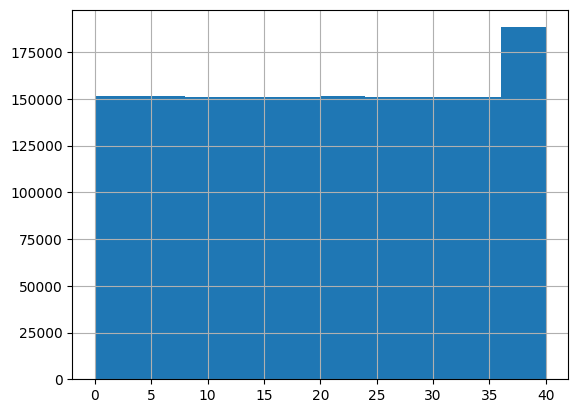

In [6]:
# Plot do histograma da variável Alvo (Quantitativa)
df['perceived_stress_score'].hist()

### Excluindo variaveis sem importância com a variável alvo

In [7]:
df.drop(columns=['app_name', 'user_id', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'hobbies_count', 
                'social_events_per_month', 'books_read_per_year','volunteer_hours_per_month', 'travel_frequency_per_year', 
                 'ads_viewed_per_day', 'ads_clicked_per_day','daily_steps_count', 'followers_count','notification_response_rate',
                'urban_rural', 'last_login_date','privacy_setting_level','two_factor_auth_enabled','biometric_login_used'], inplace = True)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1547896 entries, 0 to 1547895
Data columns (total 39 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   age                             1547896 non-null  int64  
 1   gender                          1547896 non-null  object 
 2   country                         1547896 non-null  object 
 3   income_level                    1547896 non-null  object 
 4   employment_status               1547896 non-null  object 
 5   education_level                 1547896 non-null  object 
 6   relationship_status             1547896 non-null  object 
 7   has_children                    1547896 non-null  object 
 8   exercise_hours_per_week         1547896 non-null  float64
 9   sleep_hours_per_night           1547896 non-null  float64
 10  diet_quality                    1547896 non-null  object 
 11  smoking                         1547896 non-null  object 
 12  

In [9]:
# Limpando algumas variáveis, após isso irei separar as variáveis em Quantitativa e Qualitativa para conseguir analisar com maior precisão
df.drop(columns=[
    'subscription_status','uses_premium_features', 'dms_received_per_week', 'sessions_per_day', 'account_creation_year'
], inplace = True)

In [10]:
df.select_dtypes(include=['float64', 'int64']).head(5)

,age,exercise_hours_per_week,sleep_hours_per_night,perceived_stress_score,self_reported_happiness,body_mass_index,weekly_work_hours,daily_active_minutes_instagram,posts_created_per_week,reels_watched_per_day,...,comments_written_per_day,dms_sent_per_week,time_on_feed_per_day,time_on_explore_per_day,time_on_messages_per_day,time_on_reels_per_day,following_count,average_session_length_minutes,linked_accounts_count,user_engagement_score
0,51,7.2,7.7,3,8,20.8,49.9,5.0,3,42,...,5,12,2,1,1,2,647,5.0,0,7.83
1,64,10.9,8.6,1,1,23.5,15.6,74.0,3,78,...,15,18,31,19,16,19,3511,14.8,3,1.43
2,41,5.0,6.7,4,10,28.6,31.8,5.0,7,29,...,6,12,3,1,1,1,6761,5.0,1,9.67
3,27,10.6,6.5,18,1,22.5,43.4,233.0,5,241,...,36,31,108,64,52,64,1193,25.9,1,0.94
4,55,7.7,6.8,19,1,28.1,50.2,184.0,5,146,...,36,29,78,55,22,55,1072,13.1,0,1.03


In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1547896.0,38.985440,15.294528,13.00,26.0,39.0,52.00,65.00
exercise_hours_per_week,1547896.0,7.143480,3.994556,0.00,4.0,6.6,9.70,24.10
sleep_hours_per_night,1547896.0,6.999384,1.097098,3.00,6.3,7.0,7.70,10.00
perceived_stress_score,1547896.0,19.987738,11.832578,0.00,10.0,20.0,30.00,40.00
self_reported_happiness,1547896.0,5.499804,2.871232,1.00,3.0,5.0,8.00,10.00
body_mass_index,1547896.0,25.000837,3.976188,15.00,22.3,25.0,27.70,45.00
weekly_work_hours,1547896.0,40.001454,9.997320,0.00,33.2,40.0,46.80,80.00
daily_active_minutes_instagram,1547896.0,188.229792,110.127772,5.00,101.0,186.0,271.00,580.00
posts_created_per_week,1547896.0,5.960338,3.888248,0.00,3.0,5.0,8.00,30.00
reels_watched_per_day,1547896.0,175.608146,76.220396,18.00,117.0,176.0,235.00,300.00


In [12]:
df.select_dtypes(include=['object']).head(5)

,gender,country,income_level,employment_status,education_level,relationship_status,has_children,diet_quality,smoking,alcohol_frequency,content_type_preference,preferred_content_theme
0,Female,India,High,Retired,Bachelor’s,Single,No,Good,No,Rarely,Mixed,Tech
1,Female,United Kingdom,Middle,Full-time employed,Other,Divorced,No,Very poor,No,Rarely,Photos,Fashion
2,Female,Canada,Middle,Student,Bachelor’s,In a relationship,No,Good,No,Rarely,Mixed,Other
3,Non-binary,South Korea,Middle,Unemployed,Master’s,In a relationship,No,Poor,Yes,Never,Stories,Tech
4,Male,India,Upper-middle,Full-time employed,Bachelor’s,Single,No,Average,No,Never,Videos,Food


In [13]:
df.select_dtypes(include = ['object']).describe().T

,count,unique,top,freq
gender,1547896,4,Male,743169
country,1547896,10,United States,386829
income_level,1547896,5,Middle,465037
employment_status,1547896,6,Full-time employed,695383
education_level,1547896,6,Bachelor’s,541083
relationship_status,1547896,5,Single,619236
has_children,1547896,2,No,1115158
diet_quality,1547896,5,Average,543910
smoking,1547896,3,No,1160179
alcohol_frequency,1547896,5,Rarely,541778


<h3> 2️⃣<b> Pré processamento de dados em Variáveis Qualitativas e Quantitativas</b>

In [14]:
# Separando as features de acordo com o tipo
var_qualitativas = df.select_dtypes(include = ['object'])

### Explorando dados Qualitativos

In [15]:
var_qualitativas.head()

,gender,country,income_level,employment_status,education_level,relationship_status,has_children,diet_quality,smoking,alcohol_frequency,content_type_preference,preferred_content_theme
0,Female,India,High,Retired,Bachelor’s,Single,No,Good,No,Rarely,Mixed,Tech
1,Female,United Kingdom,Middle,Full-time employed,Other,Divorced,No,Very poor,No,Rarely,Photos,Fashion
2,Female,Canada,Middle,Student,Bachelor’s,In a relationship,No,Good,No,Rarely,Mixed,Other
3,Non-binary,South Korea,Middle,Unemployed,Master’s,In a relationship,No,Poor,Yes,Never,Stories,Tech
4,Male,India,Upper-middle,Full-time employed,Bachelor’s,Single,No,Average,No,Never,Videos,Food


In [16]:
# Criando função para plot
def count_plot(title, df):
    fig, axes = plt.subplots(1,1, figsize = (10,4))
    fig.suptitle(f'Distribuição da variável {title}')
    sns.countplot(data = df, x = f'{title}')

In [17]:
employment_freq = var_qualitativas['employment_status'].value_counts()
employment_freq

employment_status
Full-time employed    695383
Student               340286
Freelancer            186330
Unemployed            155499
Part-time             123784
Retired                46614
Name: count, dtype: int64

In [18]:
# representação em %
employment_freq / df.shape[0] * 100

employment_status
Full-time employed    44.924401
Student               21.983777
Freelancer            12.037630
Unemployed            10.045830
Part-time              7.996920
Retired                3.011443
Name: count, dtype: float64

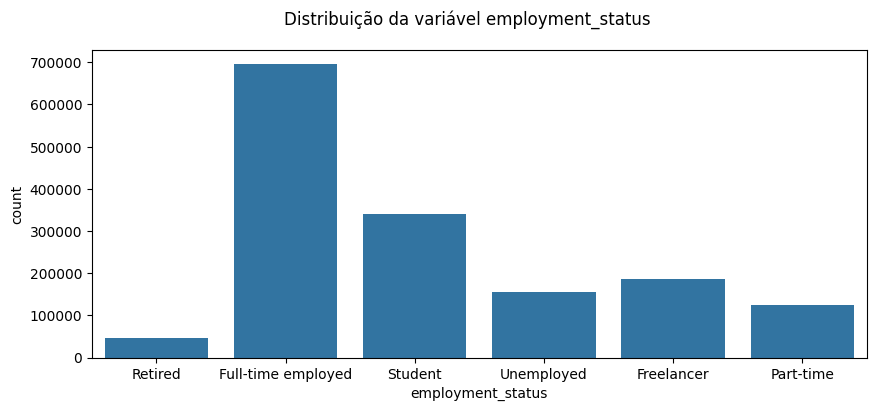

In [19]:
# Plotando a variável employment_status
employment_status = count_plot("employment_status", var_qualitativas)

In [20]:
diet_quality_freq = var_qualitativas.diet_quality.value_counts()
diet_quality_freq

diet_quality
Average      543910
Good         386255
Poor         308320
Very poor    154905
Excellent    154506
Name: count, dtype: int64

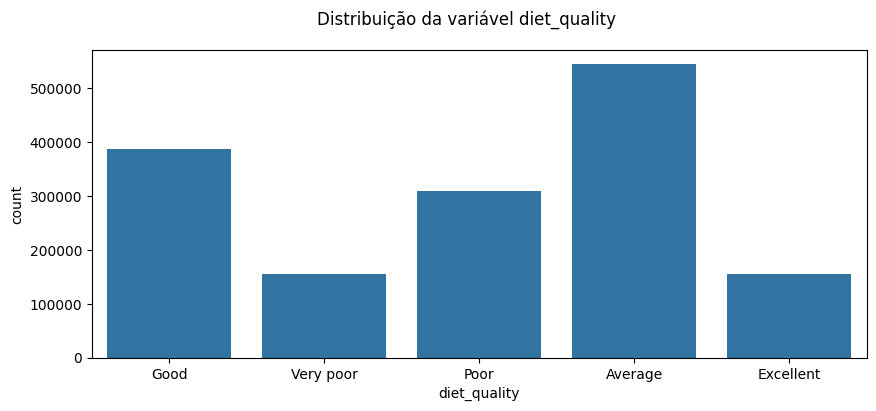

In [21]:
# Plotando a coluna diet_quality
count_plot('diet_quality', var_qualitativas)

In [22]:
freq_education_level = var_qualitativas['education_level'].value_counts()
freq_education_level

education_level
Bachelor’s      541083
High school     387323
Some college    309922
Master’s        185651
Other            77295
PhD              46622
Name: count, dtype: int64

In [23]:
# Representação em %
freq_education_level / var_qualitativas.shape[0] * 100

education_level
Bachelor’s      34.956031
High school     25.022547
Some college    20.022146
Master’s        11.993764
Other            4.993553
PhD              3.011959
Name: count, dtype: float64

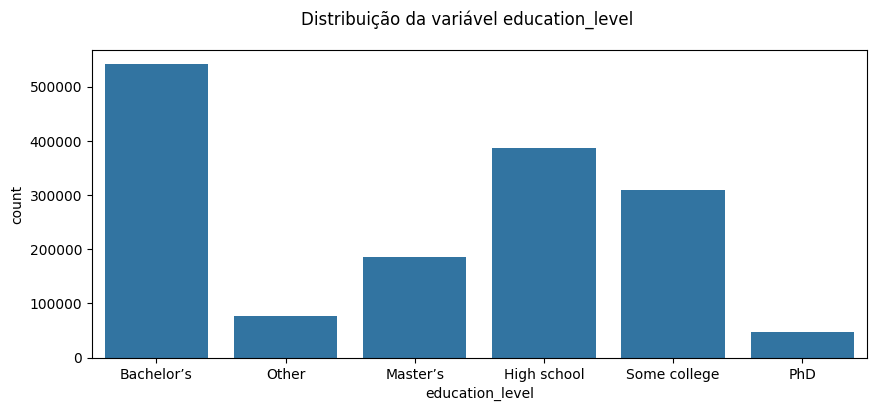

In [24]:
# Plotando a coluna education_level
count_plot('education_level', var_qualitativas)

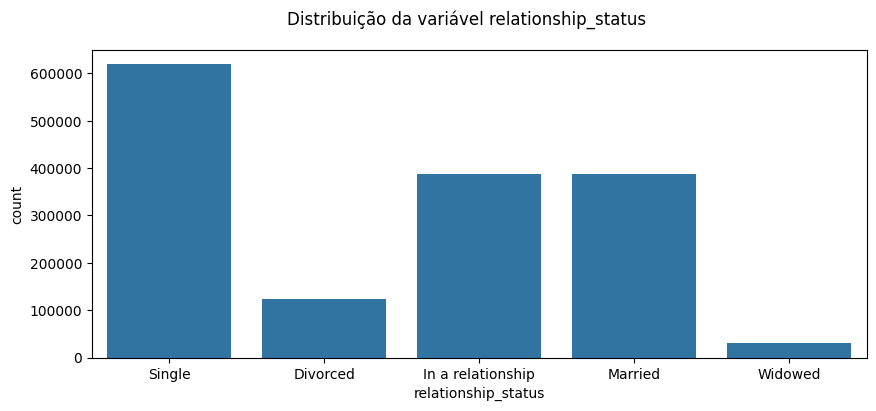

In [25]:
# Plotando a variavel relationship_status
count_plot('relationship_status', var_qualitativas)

In [26]:
# Criando tabela de Frequencia de education_level
tab_freq_relationship_status = var_qualitativas['relationship_status'].value_counts()
tab_freq_relationship_status

relationship_status
Single               619236
Married              387146
In a relationship    387085
Divorced             123591
Widowed               30838
Name: count, dtype: int64

In [27]:
tab_freq_relationship_status / var_qualitativas.shape[0] * 100

relationship_status
Single               40.005013
Married              25.011112
In a relationship    25.007171
Divorced              7.984451
Widowed               1.992253
Name: count, dtype: float64

> Devido ao número baixo de representação, linhas abaixo de 5% serão removidass evitando ruidos

In [28]:
new_df = df.copy()
new_df = new_df[(new_df['relationship_status'] != 'Widowed')]
new_df = new_df[new_df['education_level'] != 'PhD']
new_df = new_df[(new_df['employment_status'] != 'Retired')]
new_df.head()

,age,gender,country,income_level,employment_status,education_level,relationship_status,has_children,exercise_hours_per_week,sleep_hours_per_night,...,time_on_feed_per_day,time_on_explore_per_day,time_on_messages_per_day,time_on_reels_per_day,following_count,average_session_length_minutes,content_type_preference,preferred_content_theme,linked_accounts_count,user_engagement_score
1,64,Female,United Kingdom,Middle,Full-time employed,Other,Divorced,No,10.9,8.6,...,31,19,16,19,3511,14.8,Photos,Fashion,3,1.43
2,41,Female,Canada,Middle,Student,Bachelor’s,In a relationship,No,5.0,6.7,...,3,1,1,1,6761,5.0,Mixed,Other,1,9.67
3,27,Non-binary,South Korea,Middle,Unemployed,Master’s,In a relationship,No,10.6,6.5,...,108,64,52,64,1193,25.9,Stories,Tech,1,0.94
4,55,Male,India,Upper-middle,Full-time employed,Bachelor’s,Single,No,7.7,6.8,...,78,55,22,55,1072,13.1,Videos,Food,0,1.03
5,20,Male,United States,Middle,Full-time employed,Bachelor’s,Married,Yes,5.2,5.8,...,29,6,12,13,534,16.3,Photos,Food,1,1.64


In [29]:
print(f'Número de Linhas Excluídas: {df.shape[0] - new_df.shape[0]}')

Número de Linhas Excluídas: 120877


In [30]:
new_df.drop(columns = ['gender','country'], inplace = True)
new_df

,age,income_level,employment_status,education_level,relationship_status,has_children,exercise_hours_per_week,sleep_hours_per_night,diet_quality,smoking,...,time_on_feed_per_day,time_on_explore_per_day,time_on_messages_per_day,time_on_reels_per_day,following_count,average_session_length_minutes,content_type_preference,preferred_content_theme,linked_accounts_count,user_engagement_score
1,64,Middle,Full-time employed,Other,Divorced,No,10.9,8.6,Very poor,No,...,31,19,16,19,3511,14.8,Photos,Fashion,3,1.43
2,41,Middle,Student,Bachelor’s,In a relationship,No,5.0,6.7,Good,No,...,3,1,1,1,6761,5.0,Mixed,Other,1,9.67
3,27,Middle,Unemployed,Master’s,In a relationship,No,10.6,6.5,Poor,Yes,...,108,64,52,64,1193,25.9,Stories,Tech,1,0.94
4,55,Upper-middle,Full-time employed,Bachelor’s,Single,No,7.7,6.8,Average,No,...,78,55,22,55,1072,13.1,Videos,Food,0,1.03
5,20,Middle,Full-time employed,Bachelor’s,Married,Yes,5.2,5.8,Poor,No,...,29,6,12,13,534,16.3,Photos,Food,1,1.64
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1547889,34,Lower-middle,Full-time employed,Other,In a relationship,Yes,17.3,6.4,Poor,Yes,...,75,22,15,48,1784,13.5,Live,Art,1,1.23
1547890,41,Lower-middle,Full-time employed,Master’s,Married,No,10.7,6.1,Excellent,No,...,173,44,58,149,921,26.2,Videos,Food,2,0.92
1547892,42,Lower-middle,Full-time employed,Master’s,Divorced,No,3.1,6.1,Excellent,No,...,44,9,11,26,1348,38.0,Photos,Art,1,1.32
1547893,32,Low,Full-time employed,Master’s,Single,No,4.4,6.4,Average,No,...,76,19,33,48,1891,31.8,Live,Other,5,1.01


## Explorando dados Quantitativos

In [31]:
var_quantitativas = new_df.select_dtypes(include = ['float64','int64'])

In [32]:
var_quantitativas.sample(3)

,age,exercise_hours_per_week,sleep_hours_per_night,perceived_stress_score,self_reported_happiness,body_mass_index,weekly_work_hours,daily_active_minutes_instagram,posts_created_per_week,reels_watched_per_day,...,comments_written_per_day,dms_sent_per_week,time_on_feed_per_day,time_on_explore_per_day,time_on_messages_per_day,time_on_reels_per_day,following_count,average_session_length_minutes,linked_accounts_count,user_engagement_score
52687,49,5.5,7.5,8,1,24.2,46.0,141.0,6,113,...,25,25,58,18,33,32,10000,23.5,1,1.17
508559,20,3.0,8.0,9,1,22.2,62.5,156.0,3,213,...,18,18,88,34,24,36,132,22.3,2,1.03
1397091,29,2.5,7.7,24,7,28.3,43.4,195.0,1,238,...,37,24,113,44,38,39,909,17.7,4,0.94


In [33]:
var_quantitativas.corr()

,age,exercise_hours_per_week,sleep_hours_per_night,perceived_stress_score,self_reported_happiness,body_mass_index,weekly_work_hours,daily_active_minutes_instagram,posts_created_per_week,reels_watched_per_day,...,comments_written_per_day,dms_sent_per_week,time_on_feed_per_day,time_on_explore_per_day,time_on_messages_per_day,time_on_reels_per_day,following_count,average_session_length_minutes,linked_accounts_count,user_engagement_score
age,1.000000,-0.001559,0.000966,-0.000202,0.000007,0.001222,-0.000716,-0.197861,-0.461566,-0.520546,...,-0.186274,-0.177842,-0.193097,-0.171631,-0.177313,-0.185156,-0.069717,-0.058161,0.000687,0.111813
exercise_hours_per_week,-0.001559,1.000000,0.000593,-0.000230,-0.000256,-0.000015,-0.001174,0.000089,0.001478,0.000670,...,0.000375,-0.000709,-0.000191,-0.000487,0.000249,-0.000343,-0.000936,0.001640,-0.000409,-0.001179
sleep_hours_per_night,0.000966,0.000593,1.000000,-0.001636,0.000290,0.000300,-0.000674,-0.001501,-0.000630,-0.001601,...,-0.001263,-0.001029,-0.001208,-0.002006,-0.002075,-0.001302,-0.001321,0.000835,0.000524,0.000656
perceived_stress_score,-0.000202,-0.000230,-0.001636,1.000000,0.000688,0.000211,0.000745,0.834517,0.376721,0.674714,...,0.787376,0.750189,0.813547,0.724061,0.749243,0.779540,0.057047,0.159350,-0.000493,-0.436343
self_reported_happiness,0.000007,-0.000256,0.000290,0.000688,1.000000,0.000117,-0.002278,-0.372161,-0.133677,-0.295423,...,-0.351029,-0.334299,-0.362904,-0.323050,-0.333960,-0.347913,-0.020120,-0.106419,-0.001327,0.268173
body_mass_index,0.001222,-0.000015,0.000300,0.000211,0.000117,1.000000,0.000991,-0.000388,-0.000585,-0.001046,...,-0.000407,-0.001105,-0.000148,-0.000129,-0.000531,-0.000527,-0.000333,-0.000489,-0.001031,0.000238
weekly_work_hours,-0.000716,-0.001174,-0.000674,0.000745,-0.002278,0.000991,1.000000,0.001419,0.001289,0.001669,...,0.001578,0.001156,0.001445,0.001323,0.001673,0.001003,-0.000316,0.000298,-0.000711,-0.001230
daily_active_minutes_instagram,-0.197861,0.000089,-0.001501,0.834517,-0.372161,-0.000388,0.001419,1.000000,0.505903,0.874456,...,0.942991,0.899008,0.974877,0.867819,0.897813,0.934305,0.076395,0.196669,-0.000236,-0.529962
posts_created_per_week,-0.461566,0.001478,-0.000630,0.376721,-0.133677,-0.000585,0.001289,0.505903,1.000000,0.626351,...,0.477276,0.455033,0.493291,0.438556,0.453948,0.472714,0.150738,0.075428,-0.000620,-0.161220
reels_watched_per_day,-0.520546,0.000670,-0.001601,0.674714,-0.295423,-0.001046,0.001669,0.874456,0.626351,1.000000,...,0.825162,0.786196,0.852558,0.758787,0.784990,0.817107,0.094963,0.187073,-0.000276,-0.482117


In [34]:
# Criando um gráfico de Possíveis variáveis Preditoras X TARGET
numeric_var = new_df.select_dtypes(include = 'number').columns
numeric_var = numeric_var.drop('perceived_stress_score')

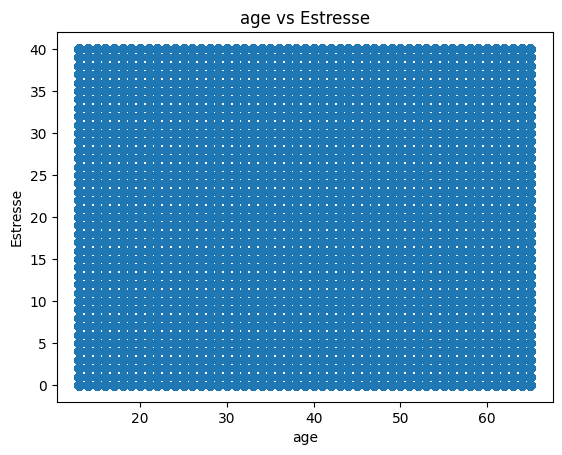

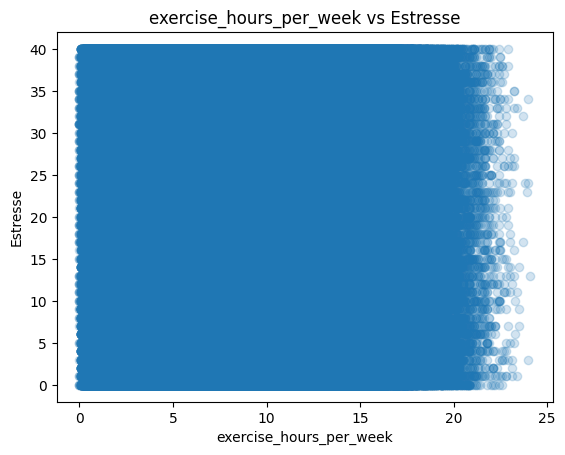

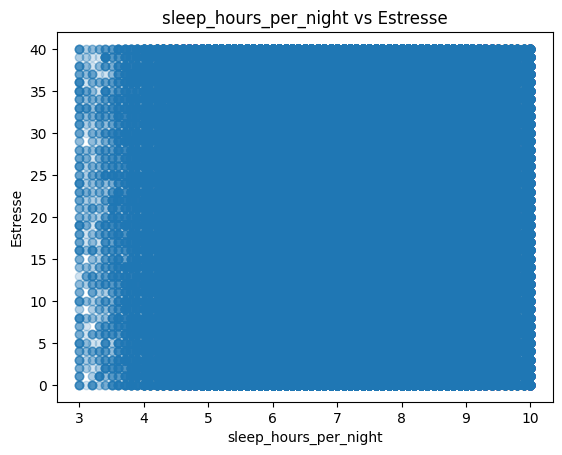

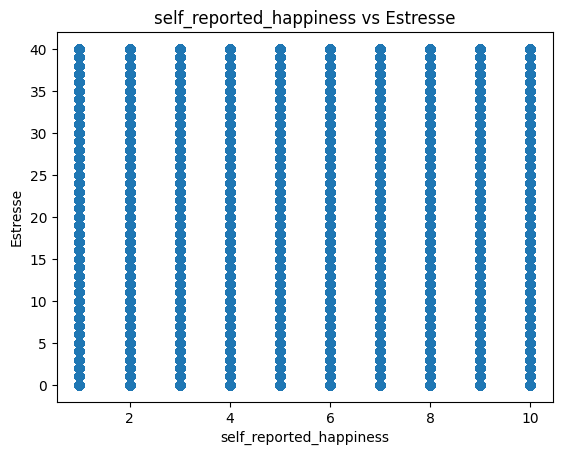

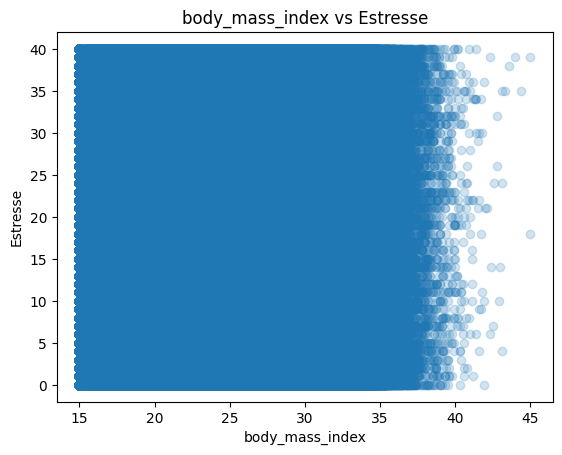

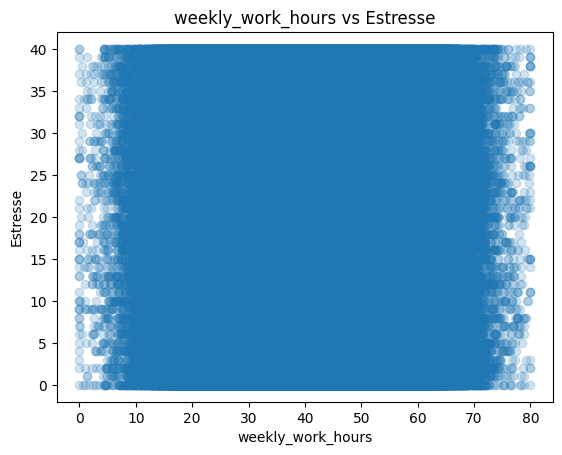

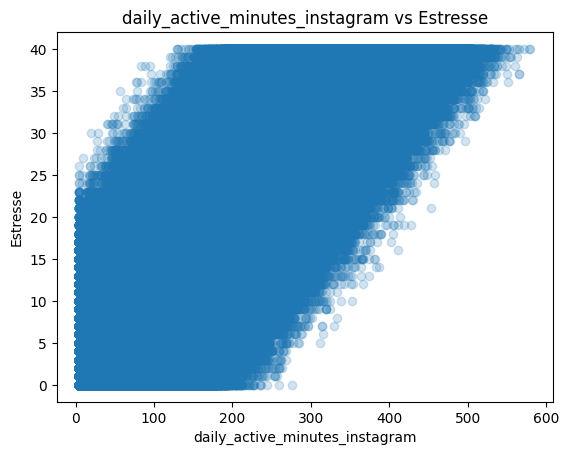

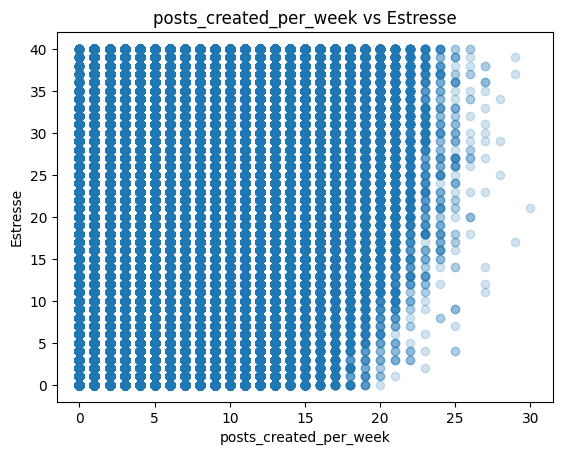

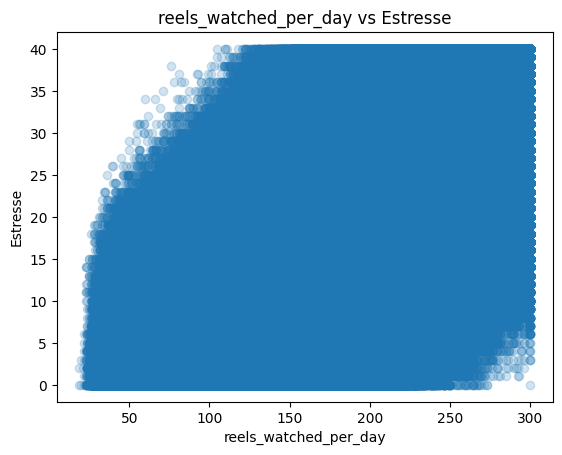

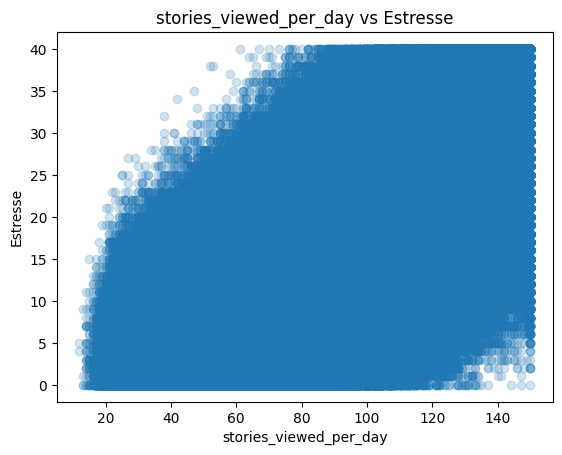

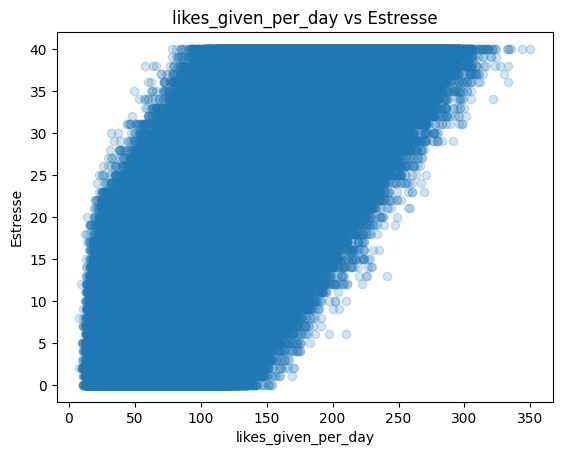

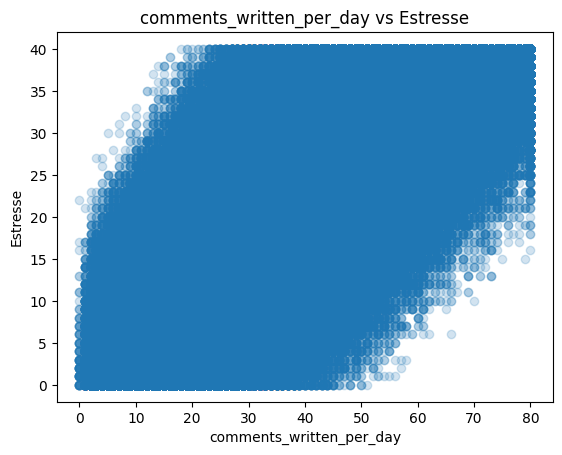

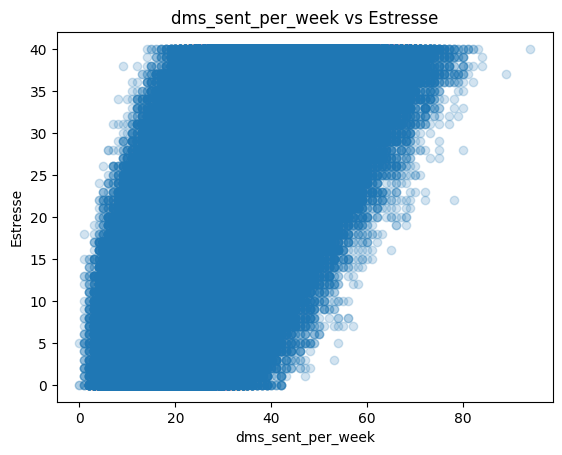

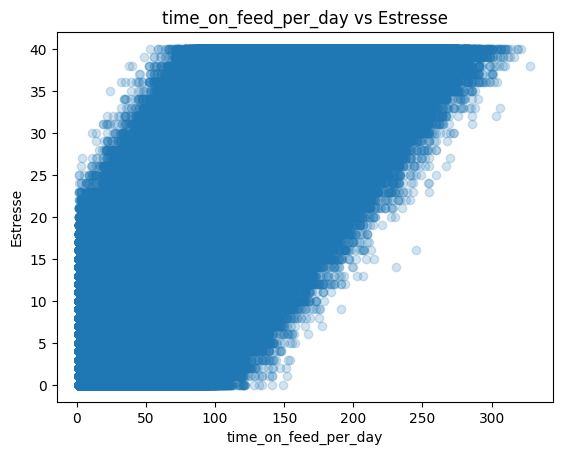

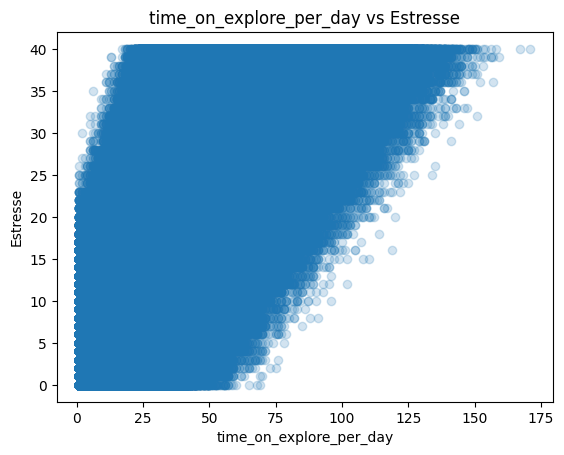

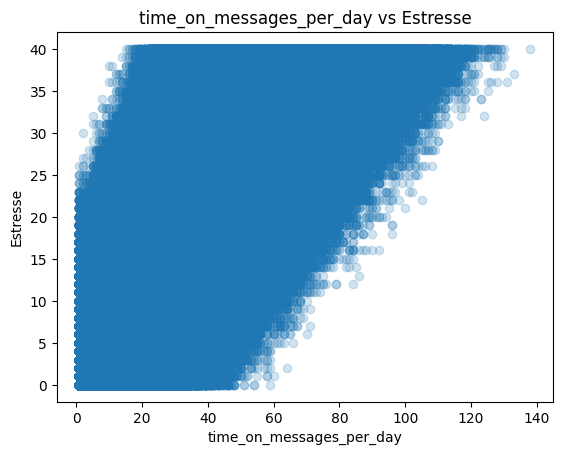

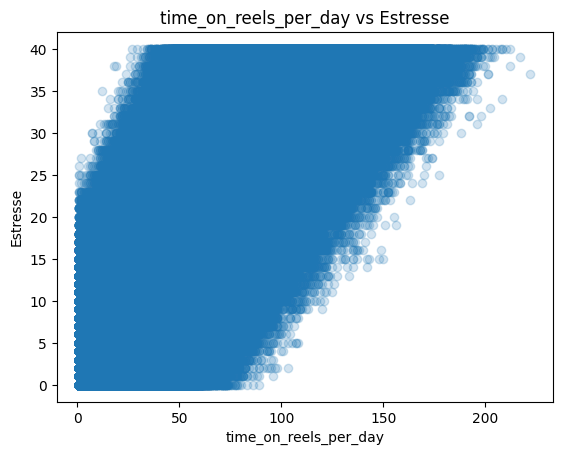

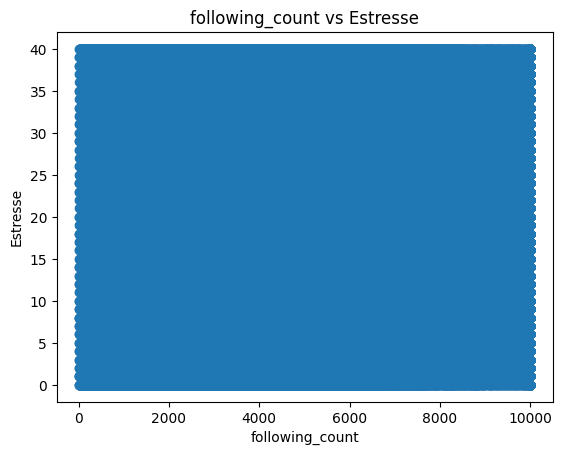

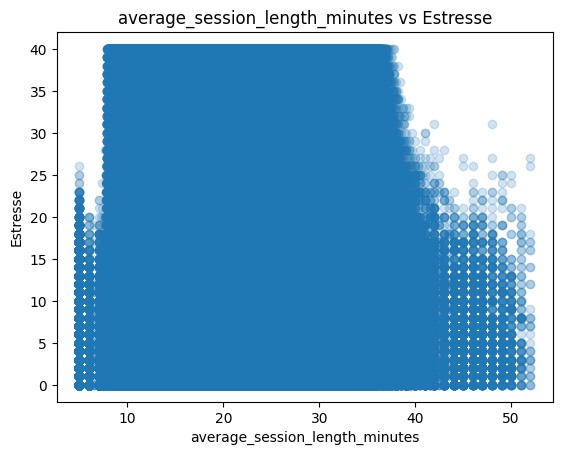

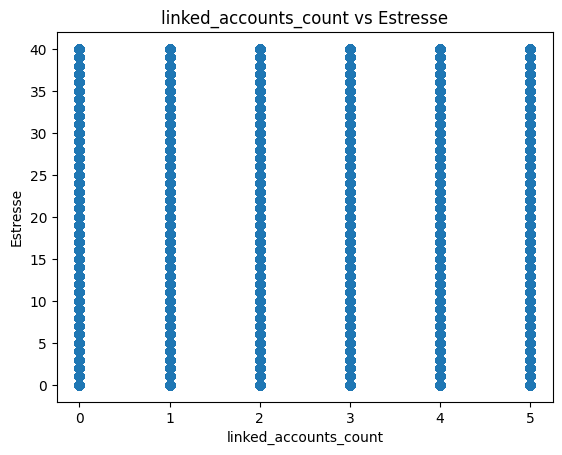

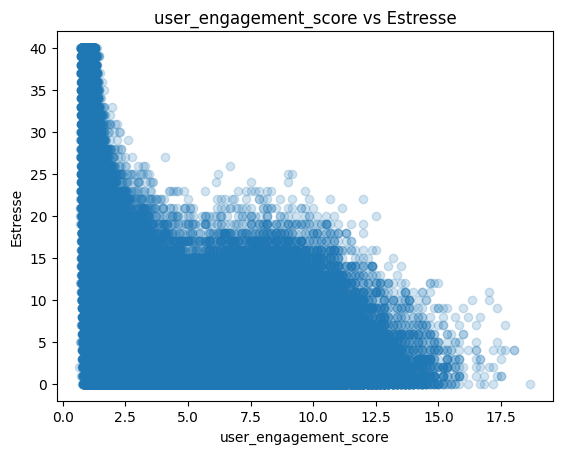

In [35]:
# Função e Visualização
for col in numeric_var:
    plt.figure()
    plt.scatter(new_df[col],new_df['perceived_stress_score'], alpha = 0.2)
    plt.xlabel(col)
    plt.ylabel('Estresse')
    plt.title(f"{col} vs Estresse")
    plt.show()

<h5><b> Filtro 1: Será removido as variáveis com baixa correlação sendo o primeiro critério:</b><p><li>Variáveis com correlação de
menores que 0.3 e menores que -0.3</b></li>
<h5><b> Filtro 2: Verificando possíveis outliers, o dataset é artificial então dificilmente irá ter, mas vale o custo de verificação</b></h5>

In [36]:
filtro_1 = var_quantitativas.corr()
filtro_1 = filtro_1[((filtro_1 >= 0.3) | (filtro_1 <= -0.3)) & (filtro_1 != 1.000)]
filtro_1 

,age,exercise_hours_per_week,sleep_hours_per_night,perceived_stress_score,self_reported_happiness,body_mass_index,weekly_work_hours,daily_active_minutes_instagram,posts_created_per_week,reels_watched_per_day,...,comments_written_per_day,dms_sent_per_week,time_on_feed_per_day,time_on_explore_per_day,time_on_messages_per_day,time_on_reels_per_day,following_count,average_session_length_minutes,linked_accounts_count,user_engagement_score
age,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.461566,-0.520546,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
exercise_hours_per_week,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sleep_hours_per_night,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
perceived_stress_score,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.834517,0.376721,0.674714,...,0.787376,0.750189,0.813547,0.724061,0.749243,0.779540,NaN,NaN,NaN,-0.436343
self_reported_happiness,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.372161,NaN,NaN,...,-0.351029,-0.334299,-0.362904,-0.323050,-0.333960,-0.347913,NaN,NaN,NaN,NaN
body_mass_index,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weekly_work_hours,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
daily_active_minutes_instagram,NaN,NaN,NaN,0.834517,-0.372161,NaN,NaN,NaN,0.505903,0.874456,...,0.942991,0.899008,0.974877,0.867819,0.897813,0.934305,NaN,NaN,NaN,-0.529962
posts_created_per_week,-0.461566,NaN,NaN,0.376721,NaN,NaN,NaN,0.505903,NaN,0.626351,...,0.477276,0.455033,0.493291,0.438556,0.453948,0.472714,NaN,NaN,NaN,NaN
reels_watched_per_day,-0.520546,NaN,NaN,0.674714,NaN,NaN,NaN,0.874456,0.626351,NaN,...,0.825162,0.786196,0.852558,0.758787,0.784990,0.817107,NaN,NaN,NaN,-0.482117


In [37]:
new_df_final = new_df[['daily_active_minutes_instagram', 'posts_created_per_week', 'reels_watched_per_day', 'stories_viewed_per_day',
                    'likes_given_per_day','comments_written_per_day','dms_sent_per_week', 'time_on_feed_per_day', 'time_on_explore_per_day',
                    'time_on_messages_per_day', 'time_on_reels_per_day', 'perceived_stress_score']]

In [38]:
new_df_final

,daily_active_minutes_instagram,posts_created_per_week,reels_watched_per_day,stories_viewed_per_day,likes_given_per_day,comments_written_per_day,dms_sent_per_week,time_on_feed_per_day,time_on_explore_per_day,time_on_messages_per_day,time_on_reels_per_day,perceived_stress_score
1,74.0,3,78,54,68,15,18,31,19,16,19,1
2,5.0,7,29,26,25,6,12,3,1,1,1,4
3,233.0,5,241,109,132,36,31,108,64,52,64,18
4,184.0,5,146,113,103,36,29,78,55,22,55,19
5,49.0,3,150,41,55,9,13,29,6,12,13,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1547889,148.0,5,137,76,109,30,21,75,22,15,48,31
1547890,419.0,7,300,150,235,65,42,173,44,58,149,39
1547892,76.0,6,88,61,60,12,11,44,9,11,26,8
1547893,159.0,4,156,91,92,29,29,76,19,33,48,4


## Treinando Modelos

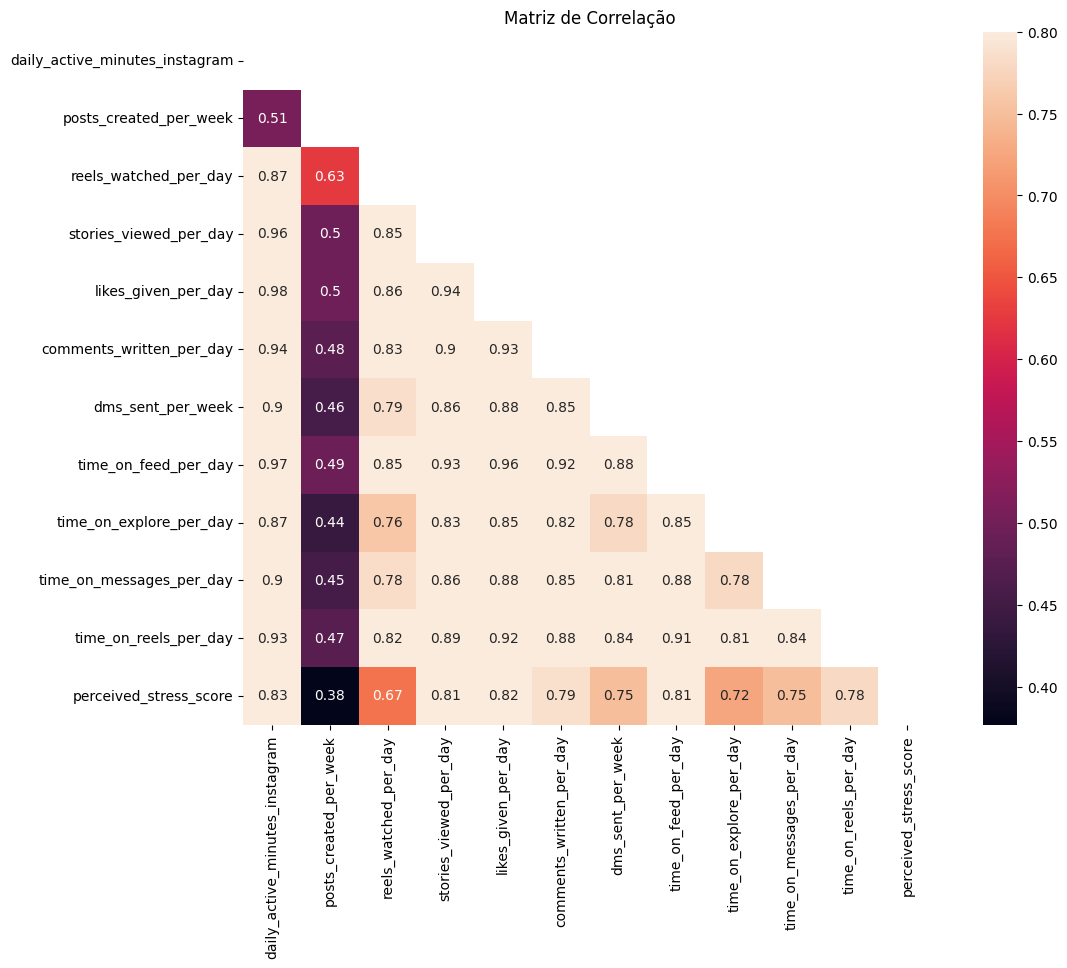

In [39]:
# Visuando as correlações por Mapa de Calor
corrmat = new_df_final.corr()
fig = plt.figure(figsize = (12,9))
mask = np.triu(np.ones_like(corrmat, dtype = bool))
sns.heatmap(corrmat, vmax = .8, mask = mask, square = True, annot = True)
plt.title("Matriz de Correlação")
plt.show()

In [40]:
new_df_final.head()

,daily_active_minutes_instagram,posts_created_per_week,reels_watched_per_day,stories_viewed_per_day,likes_given_per_day,comments_written_per_day,dms_sent_per_week,time_on_feed_per_day,time_on_explore_per_day,time_on_messages_per_day,time_on_reels_per_day,perceived_stress_score
1,74.0,3,78,54,68,15,18,31,19,16,19,1
2,5.0,7,29,26,25,6,12,3,1,1,1,4
3,233.0,5,241,109,132,36,31,108,64,52,64,18
4,184.0,5,146,113,103,36,29,78,55,22,55,19
5,49.0,3,150,41,55,9,13,29,6,12,13,1


In [41]:
new_df_final.describe().T

,count,mean,std,min,25%,50%,75%,max
daily_active_minutes_instagram,1427019.0,188.239100,110.138603,5.0,101.0,186.0,271.0,580.0
posts_created_per_week,1427019.0,5.961011,3.888759,0.0,3.0,5.0,8.0,30.0
reels_watched_per_day,1427019.0,175.615135,76.221066,19.0,117.0,176.0,235.0,300.0
stories_viewed_per_day,1427019.0,101.162181,38.793313,12.0,70.0,104.0,139.0,150.0
likes_given_per_day,1427019.0,119.114267,56.154441,8.0,75.0,118.0,161.0,350.0
comments_written_per_day,1427019.0,34.214488,17.467110,0.0,20.0,33.0,47.0,80.0
dms_sent_per_week,1427019.0,28.817527,12.246455,0.0,19.0,28.0,37.0,94.0
time_on_feed_per_day,1427019.0,94.135784,56.503656,2.0,50.0,92.0,135.0,328.0
time_on_explore_per_day,1427019.0,37.623446,25.362806,1.0,18.0,34.0,53.0,171.0
time_on_messages_per_day,1427019.0,32.954696,21.448261,1.0,16.0,31.0,47.0,138.0


### Modelo v1 Regressão Linear - Variáveis com correlação representativa

In [42]:
# Etapa 1: Preparação dos dados
target = 'perceived_stress_score'
X = new_df_final.drop(columns= [target])
y = new_df_final[target]

In [43]:
# Etapa 2: Sepração Treino/Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [44]:
# Etapa 3: Padronização dos dados
# Devido ao modelo de Regressão Linear ser sensível as variações de dados, vamos aplicar uma técnica de padronização
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [45]:
# Etapa 4: Importar e treinar o modelo
modelo_v1 = LinearRegression()
modelo_v1.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [46]:
# Prevendo valores
pred_1 = modelo_v1.predict(X_test)

In [47]:
# Etapa 5: Avaliação do modelo
print("R2: ", r2_score(y_test, pred_1))
print("RMSE: ", np.sqrt(mean_squared_error(y_test, pred_1)))

R2:  0.714291430815495
RMSE:  6.324829579897799


In [48]:
# Visualizando Coeficientes
coeficientes = pd.Series(modelo_v1.coef_, index = X.columns).sort_values(ascending = False)
coeficientes

daily_active_minutes_instagram    9.740705
stories_viewed_per_day            2.763363
comments_written_per_day          0.038361
likes_given_per_day               0.028327
time_on_feed_per_day              0.020451
time_on_messages_per_day          0.006968
dms_sent_per_week                -0.007725
time_on_explore_per_day          -0.012731
time_on_reels_per_day            -0.023719
posts_created_per_week           -0.053956
reels_watched_per_day            -2.890154
dtype: float64

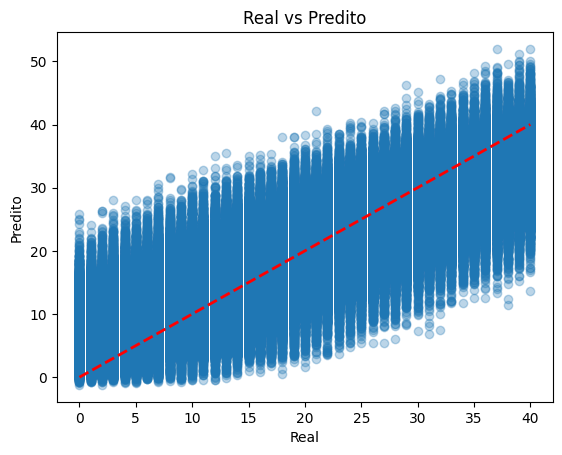

In [49]:
# Visualizando Dados Reais x Preditos
plt.figure()
plt.scatter(y_test, pred_1, alpha=0.3)
plt.plot([0,40],[0,40], color = 'red', linewidth=2, linestyle='--')
plt.xlabel("Real")
plt.ylabel("Predito")
plt.title("Real vs Predito")
plt.show()

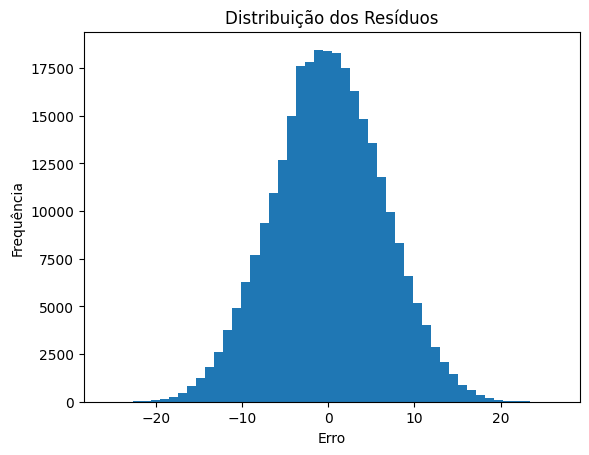

In [50]:
# Visualizando residuos
residuos = y_test - pred_1
plt.figure()
plt.hist(residuos, bins=50)
plt.title("Distribuição dos Resíduos")
plt.xlabel("Erro")
plt.ylabel("Frequência")
plt.show()

### Modelo v2 Regressão Linear - Com todas variáveis

In [51]:
# Modelo com variáveis mais significantes após testes de coeficientes
df_2 = df.select_dtypes(include=['float64', 'int64'])

In [52]:
# Etapa 1 Preparação dos dados
target = 'perceived_stress_score'
X = df_2.drop(columns = [target])
y = df_2[target]

In [53]:
# Etapa 2 Separação de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state = 42)

In [54]:
# Etapa 3: Padronizando os dados
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [55]:
# Etapa 4 Treinamento do modelo
modelo_v2 = LinearRegression()
modelo_v2.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [56]:
# Etapa 5 Prevendo dados
pred_v2 = modelo_v2.predict(X_test)

In [57]:
# Etapa 6 Avaliar o modelo
print(f"R2: ", r2_score(y_test, pred_v2))
print(f"RMSE: ", np.sqrt(mean_squared_error(y_test, pred_v2)))

R2:  0.8496538152573423
RMSE:  4.592197190642725


In [58]:
# Visualizando Coeficientes
coeficientes_2 = pd.Series(modelo_v2.coef_, index = X.columns).sort_values(ascending = False)
coeficientes_2

daily_active_minutes_instagram    10.393470
self_reported_happiness            4.481571
age                                2.437912
stories_viewed_per_day             1.248789
posts_created_per_week             0.141120
likes_given_per_day                0.088456
comments_written_per_day           0.076060
reels_watched_per_day              0.057636
average_session_length_minutes     0.022033
time_on_feed_per_day               0.019027
weekly_work_hours                  0.004848
body_mass_index                    0.003656
following_count                    0.002247
linked_accounts_count             -0.000284
time_on_reels_per_day             -0.003001
exercise_hours_per_week           -0.003148
time_on_explore_per_day           -0.004137
dms_sent_per_week                 -0.006195
sleep_hours_per_night             -0.006446
time_on_messages_per_day          -0.007462
user_engagement_score             -0.285078
dtype: float64

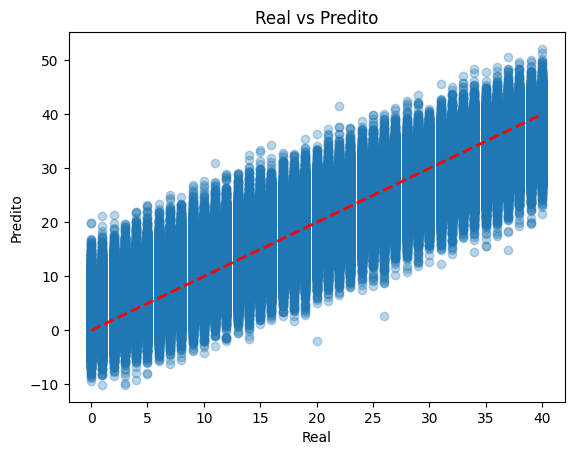

In [59]:
# Visualizando Dados Reais x Preditos
plt.figure()
plt.scatter(y_test, pred_v2, alpha=0.3)
plt.plot([0,40],[0,40], color = 'red', linewidth=2, linestyle='--')
plt.xlabel("Real")
plt.ylabel("Predito")
plt.title("Real vs Predito")
plt.show()

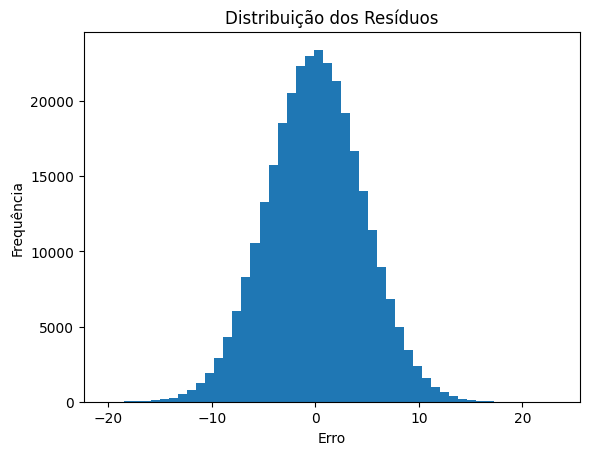

In [60]:
# Visualizando Residuos
residuos = y_test - pred_v2
plt.figure()
plt.hist(residuos, bins=50)
plt.title("Distribuição dos Resíduos")
plt.xlabel("Erro")
plt.ylabel("Frequência")
plt.show()

><b> Após diversos testes de experimentações, o modelo V2 apresentou melhor desempenho (R2 ~ 84%) que o modelo V1 (R2~70%), impulsionado pela variavel self_reported_happiness.
>
> <li>Mesmo não possuindo alta correlação bivariada com a variável alvo, a variável self_reported_happiness possui correlação com outras variáveis comportamentais relevantes.
> <br><li>Manter esta variável acaba acarretando multicolinearidade, indicando uma redundância estrutural entre felicidade e variáveis comportamentais, apesar de sua inclusão reduzir de maneira significativa o erro preditivo, é necessário manter caute-la ao interpreta-la e mante-la.

## Modelagem Estatística

###  Modelo Estatístico OLS v1

In [61]:
variaveis_modelagem = new_df_final.drop(columns=['perceived_stress_score'])
variaveis_modelagem = variaveis_modelagem.columns
variaveis_modelagem

Index(['daily_active_minutes_instagram', 'posts_created_per_week',
       'reels_watched_per_day', 'stories_viewed_per_day',
       'likes_given_per_day', 'comments_written_per_day', 'dms_sent_per_week',
       'time_on_feed_per_day', 'time_on_explore_per_day',
       'time_on_messages_per_day', 'time_on_reels_per_day'],
      dtype='object')

In [62]:
# Variável alvo x variaveis preditoras
formula = 'perceived_stress_score ~ self_reported_happiness+daily_active_minutes_instagram+ posts_created_per_week+reels_watched_per_day+stories_viewed_per_day+ \
likes_given_per_day + comments_written_per_day +dms_sent_per_week+time_on_feed_per_day+time_on_explore_per_day+time_on_messages_per_day+time_on_reels_per_day'

In [63]:
# Cria e treina modelo
modelo_estatistico_v1 = ols(formula, data = df).fit()

In [64]:
# Coeficiente de determinação
print(f'R-squared: {modelo_estatistico_v1.rsquared}')

R-squared: 0.8309769098611137


In [65]:
# Coeficientes
print(f'R-squared: {modelo_estatistico_v1.params}')

R-squared: Intercept                        -7.486682
self_reported_happiness           1.524366
daily_active_minutes_instagram    0.111148
posts_created_per_week           -0.072288
reels_watched_per_day            -0.042588
stories_viewed_per_day            0.058791
likes_given_per_day               0.000524
comments_written_per_day          0.002448
dms_sent_per_week                -0.000757
time_on_feed_per_day              0.000359
time_on_explore_per_day          -0.000113
time_on_messages_per_day         -0.000357
time_on_reels_per_day            -0.000183
dtype: float64


In [66]:
modelo_estatistico_v1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                              
==================================================================================
Dep. Variable:     perceived_stress_score   R-squared:                       0.831
Model:                                OLS   Adj. R-squared:                  0.831
Method:                     Least Squares   F-statistic:                 6.342e+05
Date:                    Tue, 17 Mar 2026   Prob (F-statistic):               0.00
Time:                            17:08:14   Log-Likelihood:            -4.6451e+06
No. Observations:                 1547896   AIC:                         9.290e+06
Df Residuals:                     1547883   BIC:                         9.290e+06
Df Model:                              12                                         
Covariance Type:                nonrobust                                         
==================================================================================================
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                         -7.4867      0.022   -334.708      0.000      -7.531      -7.443
self_reported_happiness            1.5244      0.001   1034.992      0.000       1.521       1.527
daily_active_minutes_instagram     0.1111      0.000    339.941      0.000       0.111       0.112
posts_created_per_week            -0.0723      0.001    -55.655      0.000      -0.075      -0.070
reels_watched_per_day             -0.0426      0.000   -360.057      0.000      -0.043      -0.042
stories_viewed_per_day             0.0588      0.000    171.423      0.000       0.058       0.059
likes_given_per_day                0.0005      0.000      1.462      0.144      -0.000       0.001
comments_written_per_day           0.0024      0.001      3.639      0.000       0.001       0.004
dms_sent_per_week                 -0.0008      0.001     -1.038      0.299      -0.002       0.001
time_on_feed_per_day               0.0004      0.000      1.156      0.248      -0.000       0.001
time_on_explore_per_day           -0.0001      0.000     -0.365      0.715      -0.001       0.000
time_on_messages_per_day          -0.0004      0.000     -0.862      0.389      -0.001       0.000
time_on_reels_per_day             -0.0002      0.000     -0.591      0.554      -0.001       0.000
==============================================================================
Omnibus:                      267.780   Durbin-Watson:                   2.001
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              267.637
Skew:                           0.031   Prob(JB):                     7.65e-59
Kurtosis:                       2.984   Cond. No.                     2.09e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.09e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Devido ao P>|t| Alto de algumas variáveis demonstrando multicolinearidade, assim como nos modelos de r, vamos excluir aquelas com o maior indicador. Porém devido a interação de algumas variáveis,
será mantida a variável 'time_on_reels_per_day', por a manter a precisão do modelo com 70% e apresentar melhor desempenho.


### Modelo Estatístico v2

In [67]:
# Variável alvo x variaveis preditoras
formula_2 = 'perceived_stress_score ~ posts_created_per_week+reels_watched_per_day+stories_viewed_per_day+comments_written_per_day+likes_given_per_day+time_on_reels_per_day'

In [68]:
# Cria e treina modelo
modelo_estatistico_v2 = ols(formula_2, data = df).fit()

In [69]:
# Coeficiente de determinação
print(f'R-squared: {modelo_estatistico_v2.rsquared}')

R-squared: 0.7014606776772315


<p>Exluindo 5 variáveis, conseguimos manter um número próximo do modelo_v1, onde aproximadamente 70% da variabilidade de score_stess
pode ser explicada através das variráveis independentes do modelo.
Um valor bastante alto, sugerindo que os ajustes foram bem feitos</p>

In [70]:
# Coeficientes
print(f'R-squared: {modelo_estatistico_v2.params}')

R-squared: Intercept                  -1.811117
posts_created_per_week     -0.028940
reels_watched_per_day      -0.030119
stories_viewed_per_day      0.119442
comments_written_per_day    0.088695
likes_given_per_day         0.084347
time_on_reels_per_day       0.037121
dtype: float64


In [71]:
modelo_estatistico_v2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                              
==================================================================================
Dep. Variable:     perceived_stress_score   R-squared:                       0.701
Model:                                OLS   Adj. R-squared:                  0.701
Method:                     Least Squares   F-statistic:                 6.062e+05
Date:                    Tue, 17 Mar 2026   Prob (F-statistic):               0.00
Time:                            17:08:16   Log-Likelihood:            -5.0854e+06
No. Observations:                 1547896   AIC:                         1.017e+07
Df Residuals:                     1547889   BIC:                         1.017e+07
Df Model:                               6                                         
Covariance Type:                nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                   -1.8111      0.017   -105.240      0.000      -1.845      -1.777
posts_created_per_week      -0.0289      0.002    -16.791      0.000      -0.032      -0.026
reels_watched_per_day       -0.0301      0.000   -195.541      0.000      -0.030      -0.030
stories_viewed_per_day       0.1194      0.000    287.901      0.000       0.119       0.120
comments_written_per_day     0.0887      0.001    107.263      0.000       0.087       0.090
likes_given_per_day          0.0843      0.000    244.275      0.000       0.084       0.085
time_on_reels_per_day        0.0371      0.000     96.356      0.000       0.036       0.038
==============================================================================
Omnibus:                     1046.844   Durbin-Watson:                   2.000
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              968.472
Skew:                          -0.033   Prob(JB):                    5.00e-211
Kurtosis:                       2.896   Cond. No.                         879.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""